**BUISINESS UNDERSTANDING**

***BO-3: Risk Stratification and Clinical Decision Support***

Provide interpretable risk estimation and insights into tumor aggressiveness.

**DSO-3: Benign Tumor Risk Scoring and Aggressiveness Profiling**

📘 Step 2 — Data Understanding
Clearly understanding each variable is essential before any modeling. Here is a structured and clear description of the WDBC dataset columns:

Column	Description
id	Unique (anonymized) patient identifier.
diagnosis	Tumor type: M = Malignant, B = Benign.
radius_mean	Average radius: mean distance from the center to the perimeter of the nucleus.
texture_mean	Average variation in gray-level intensity (granularity).
perimeter_mean	Average perimeter length of the nuclei.
area_mean	Average area of the nuclei.
smoothness_mean	Local smoothness of the contour.
compactness_mean	Shape density (perimeter² / area).
concavity_mean	Average depth of concavities on the contour.
concave points_mean	Mean number of concave points.
symmetry_mean	Overall symmetry of the nucleus shape.
fractal_dimension_mean	Fractal complexity of the contour.
radius_se	Variability (standard error) of the radius.
texture_se	Variability of texture.
perimeter_se	Variability of the perimeter.
area_se	Variability of the area.
smoothness_se	Variability of contour smoothness.
compactness_se	Variability of compactness.
concavity_se	Variability of concavity.
concave points_se	Variability in the number of concave points.
symmetry_se	Variability of symmetry.
fractal_dimension_se	Variability of fractal dimension.
radius_worst	Mean of the 3 largest radius values.
texture_worst	Mean of the 3 highest texture values.
perimeter_worst	Mean of the 3 largest perimeter values.
area_worst	Mean of the 3 largest area measurements.
smoothness_worst	Mean of the 3 highest irregularity values.
compactness_worst	Mean of the 3 highest compactness values.
concavity_worst	Mean of the 3 deepest concavity values.
concave points_worst	Mean of the 3 largest counts of concave points.
symmetry_worst	Mean of the 3 most atypical symmetry values.
fractal_dimension_worst	Mean of the 3 highest fractal complexity values.
📝 Visual Summary
30 features → all numerical
3 families per feature: _mean, _se, _worst
Main objective: classify benign vs malignant tumors based on FNA cellular characteristics

In [11]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# =============================================================================
# 📥 STEP 2: DATA UNDERSTANDING & LOADING
# =============================================================================

print("="*80)
print("📥 LOADING DATASET")
print("="*80)

try:
    # Load the dataset
    df = pd.read_csv('data.csv')

    # Display success message and basic info
    print(f"✅ Dataset loaded successfully!")
    print(f"📊 Shape: {df.shape[0]} rows, {df.shape[1]} columns")

    # Display the first 5 rows to verify loading
    print("\n🔍 First 5 rows of the dataset:")
    display(df.head())

except FileNotFoundError:
    print("❌ Error: 'data.csv' file not found. Please ensure the file is in the same directory.")
except Exception as e:
    print(f"❌ An error occurred while loading the dataset: {e}")

print("="*80)

📥 LOADING DATASET
✅ Dataset loaded successfully!
📊 Shape: 569 rows, 33 columns

🔍 First 5 rows of the dataset:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


****DATA PREPARING****

In [13]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import shap


In [14]:
# Drop non-informative columns
df_model = df.drop(columns=["id", "Unnamed: 32"])

# Encode target
df_model["diagnosis"] = df_model["diagnosis"].map({"B": 0, "M": 1})

# Features / target
X = df_model.drop(columns=["diagnosis"])
y = df_model["diagnosis"]

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


**MODELING**

*LOGISTIC REGRESSION*


In [15]:
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    ))
])

logreg_pipeline.fit(X_train, y_train)

# Predictions
y_proba_lr = logreg_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, y_proba_lr))


Logistic Regression ROC-AUC: 0.9953703703703705


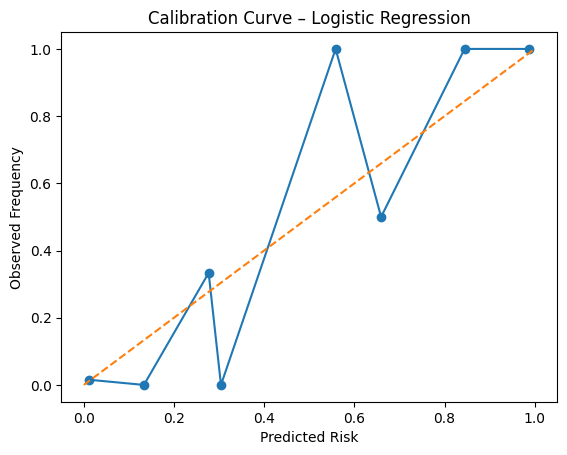

In [33]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    y_proba_lr,
    n_bins=10
)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Predicted Risk")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve – Logistic Regression")
plt.show()



In [23]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logreg_pipeline.named_steps["model"].coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

coef_df.head(10)




,Feature,Coefficient
21,texture_worst,1.464476
10,radius_se,1.307094
28,symmetry_worst,1.079550
7,concave points_mean,0.959862
15,compactness_se,-0.952922
26,concavity_worst,0.937757
13,area_se,0.927582
23,area_worst,0.899866
20,radius_worst,0.899330
12,perimeter_se,0.766343


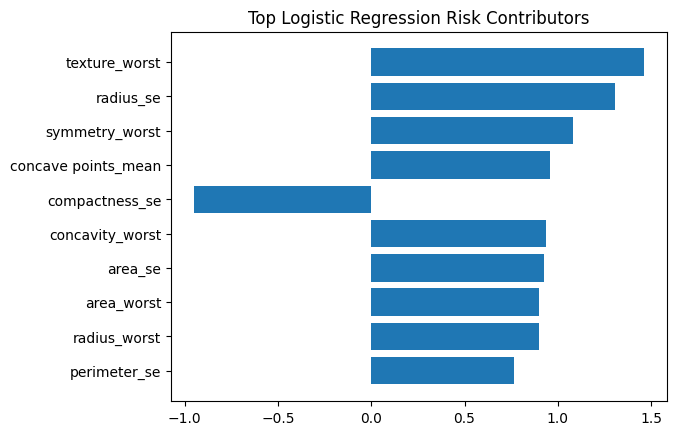

In [24]:
plt.barh(coef_df["Feature"][:10], coef_df["Coefficient"][:10])
plt.gca().invert_yaxis()
plt.title("Top Logistic Regression Risk Contributors")
plt.show()


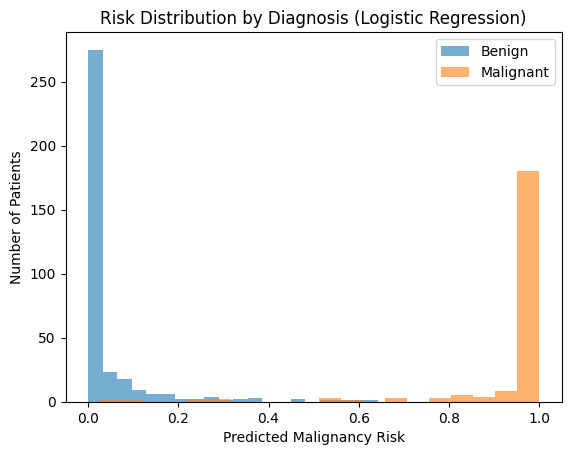

In [25]:
plt.hist(
    df_model[df_model["diagnosis"] == 0]["malignancy_risk"],
    bins=20,
    alpha=0.6,
    label="Benign"
)

plt.hist(
    df_model[df_model["diagnosis"] == 1]["malignancy_risk"],
    bins=20,
    alpha=0.6,
    label="Malignant"
)

plt.xlabel("Predicted Malignancy Risk")
plt.ylabel("Number of Patients")
plt.title("Risk Distribution by Diagnosis (Logistic Regression)")
plt.legend()
plt.show()


**RANDOM FOREST**

In [16]:
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test, y_proba_rf))


Random Forest ROC-AUC: 0.9970238095238095


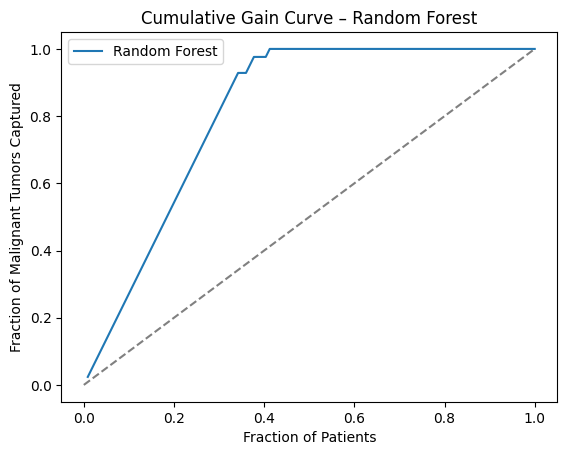

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure y_proba_rf is the probability of class 1
y_true = y_test.values
y_scores = y_proba_rf

# Sort by descending predicted probability
sorted_idx = np.argsort(-y_scores)
y_true_sorted = y_true[sorted_idx]
y_scores_sorted = y_scores[sorted_idx]

# Cumulative sum of true positives
cum_malignant = np.cumsum(y_true_sorted) / y_true.sum()
cum_patients = np.arange(1, len(y_true_sorted)+1) / len(y_true_sorted)

# Plot
plt.plot(cum_patients, cum_malignant, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--", color="gray")  # baseline
plt.xlabel("Fraction of Patients")
plt.ylabel("Fraction of Malignant Tumors Captured")
plt.title("Cumulative Gain Curve – Random Forest")
plt.legend()
plt.show()




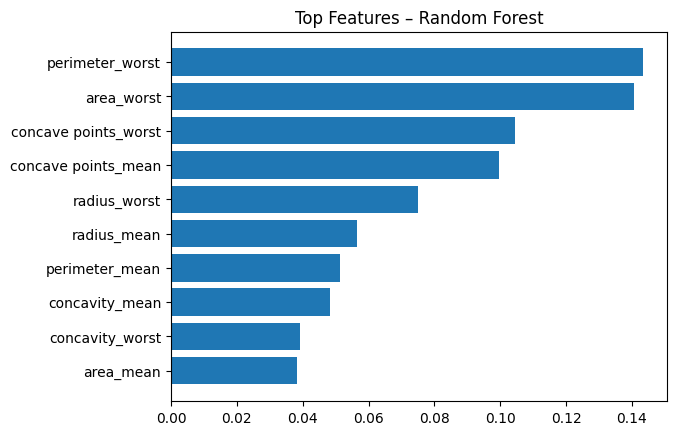

In [27]:
importances = rf_pipeline.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.barh(imp_df["Feature"][:10], imp_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top Features – Random Forest")
plt.show()


**SVM**

In [17]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

svm_pipeline.fit(X_train, y_train)

y_proba_svm = svm_pipeline.predict_proba(X_test)[:, 1]

print("SVM ROC-AUC:",
      roc_auc_score(y_test, y_proba_svm))


SVM ROC-AUC: 0.9953703703703705


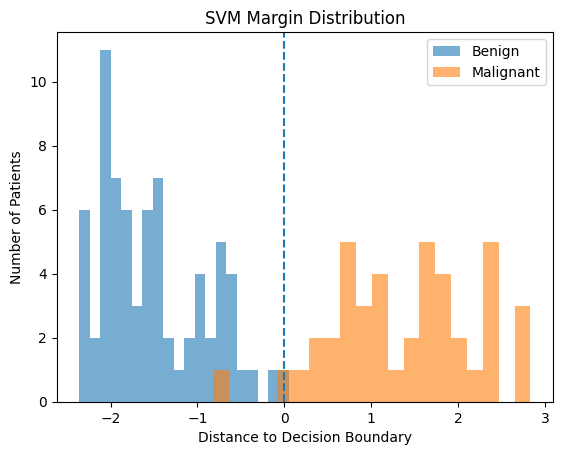

In [35]:
decision_scores = svm_pipeline.decision_function(X_test)

plt.hist(
    decision_scores[y_test == 0],
    bins=20,
    alpha=0.6,
    label="Benign"
)

plt.hist(
    decision_scores[y_test == 1],
    bins=20,
    alpha=0.6,
    label="Malignant"
)

plt.axvline(0, linestyle='--')
plt.xlabel("Distance to Decision Boundary")
plt.ylabel("Number of Patients")
plt.title("SVM Margin Distribution")
plt.legend()
plt.show()



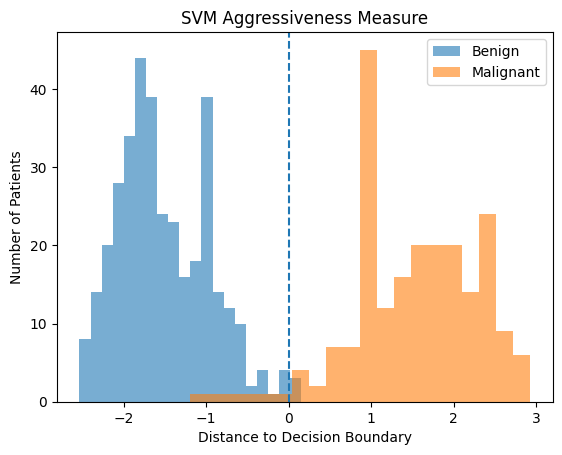

In [30]:
decision_scores = svm_pipeline.decision_function(X)

plt.hist(
    decision_scores[df_model["diagnosis"] == 0],
    bins=20,
    alpha=0.6,
    label="Benign"
)

plt.hist(
    decision_scores[df_model["diagnosis"] == 1],
    bins=20,
    alpha=0.6,
    label="Malignant"
)

plt.axvline(0, linestyle="--")
plt.xlabel("Distance to Decision Boundary")
plt.ylabel("Number of Patients")
plt.title("SVM Aggressiveness Measure")
plt.legend()
plt.show()


In [18]:
# Predict probabilities for ALL patients
df_model["malignancy_risk"] = logreg_pipeline.predict_proba(X)[:, 1]

# Select benign patients only
benign_df = df_model[df_model["diagnosis"] == 0].copy()

# Quantile-based scoring (robust)
benign_df["risk_score_1_10"] = (
    pd.qcut(
        benign_df["malignancy_risk"],
        q=10,
        labels=False
    ) + 1
)

benign_df[["malignancy_risk", "risk_score_1_10"]].head()


,malignancy_risk,risk_score_1_10
19,0.089666,9
20,0.002980,6
21,0.000044,1
37,0.000217,3
46,0.000014,1


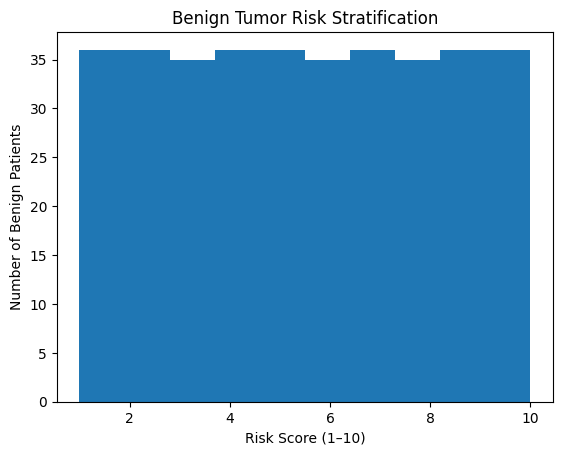

In [31]:
plt.hist(
    benign_df["risk_score_1_10"],
    bins=10
)

plt.xlabel("Risk Score (1–10)")
plt.ylabel("Number of Benign Patients")
plt.title("Benign Tumor Risk Stratification")
plt.show()


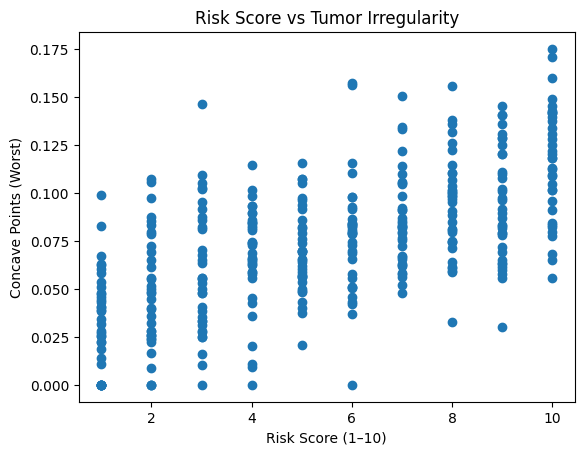

In [32]:
plt.scatter(
    benign_df["risk_score_1_10"],
    benign_df["concave points_worst"]
)

plt.xlabel("Risk Score (1–10)")
plt.ylabel("Concave Points (Worst)")
plt.title("Risk Score vs Tumor Irregularity")
plt.show()


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


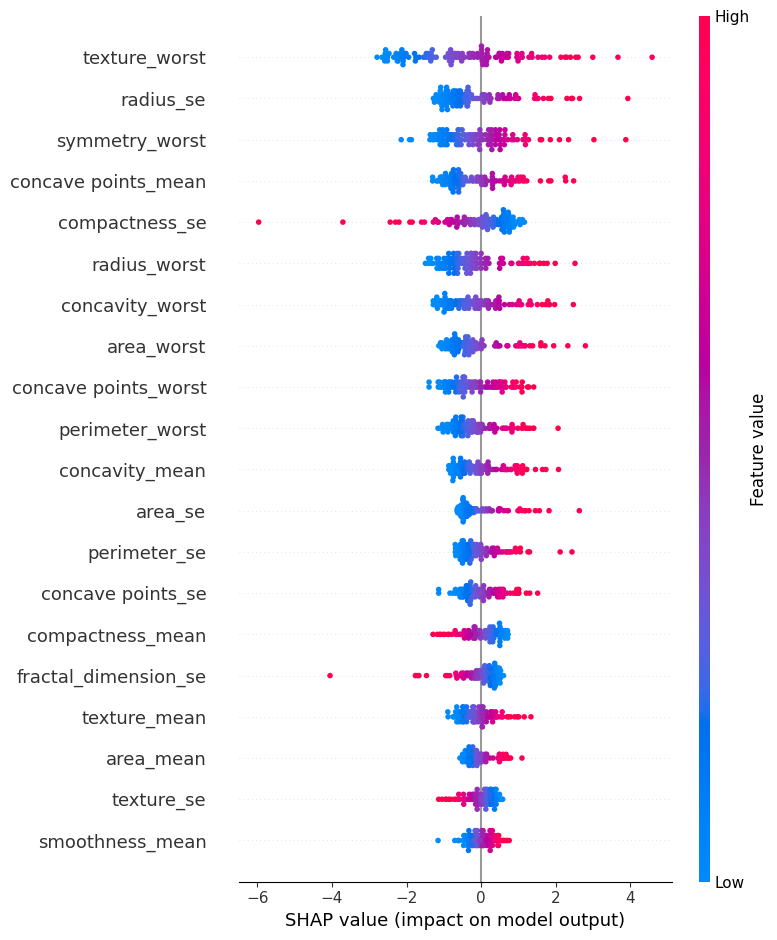

In [19]:
explainer_lr = shap.LinearExplainer(
    logreg_pipeline.named_steps["model"],
    logreg_pipeline.named_steps["scaler"].transform(X_train),
    feature_perturbation="interventional"
)

shap_values_lr = explainer_lr.shap_values(
    logreg_pipeline.named_steps["scaler"].transform(X_test)
)

shap.summary_plot(shap_values_lr, X_test)


/tmp/ipython-input-164576226.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


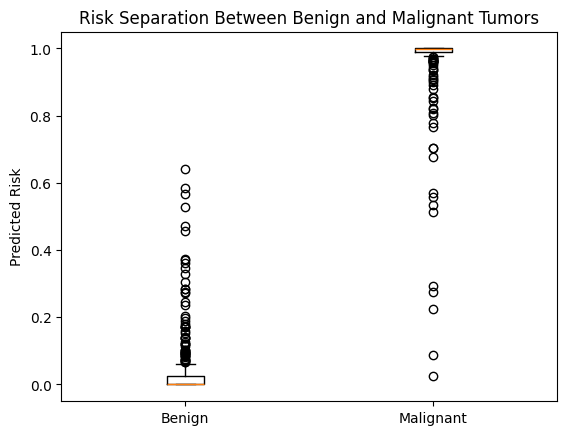

In [36]:
plt.boxplot(
    [
        benign_df["malignancy_risk"],
        df_model[df_model["diagnosis"] == 1]["malignancy_risk"]
    ],
    labels=["Benign", "Malignant"]
)

plt.ylabel("Predicted Risk")
plt.title("Risk Separation Between Benign and Malignant Tumors")
plt.show()


=== Linear Regression Regression Metrics ===
RMSE: 0.338
R2 Score: 0.904

=== Random Forest Regression Metrics ===
RMSE: 0.136
R2 Score: 0.984

=== SVM Regression Regression Metrics ===
RMSE: 0.463
R2 Score: 0.819



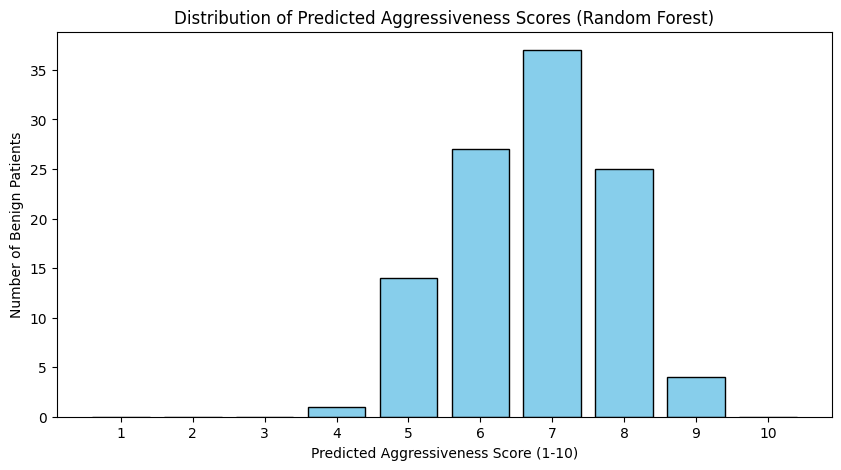

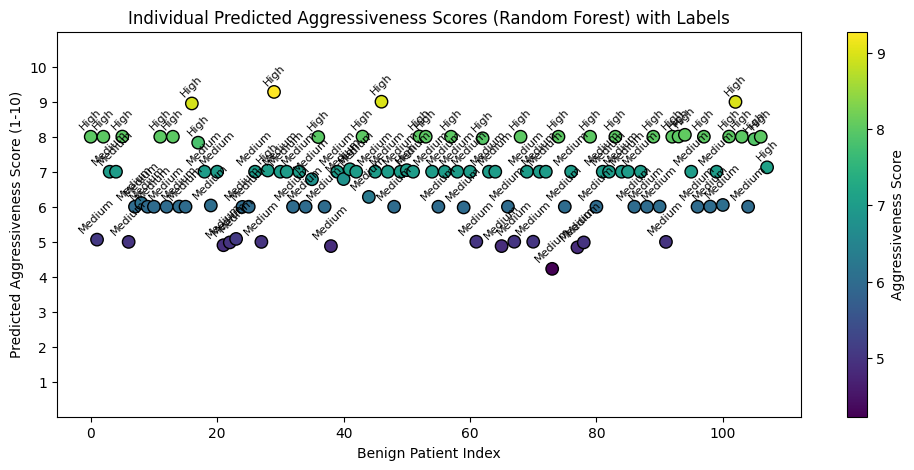

Number of patients per predicted score (1-10):
4.225     1
4.840     1
4.875     2
4.900     1
4.980     2
4.995     3
5.000     3
5.060     1
5.080     1
5.980     1
5.995     1
6.000    18
6.005     3
6.035     1
6.050     1
6.105     1
6.280     1
6.785     1
6.790     1
7.000    31
7.035     1
7.045     1
7.070     1
7.125     1
7.830     1
7.930     1
7.955     1
7.990     1
8.000    15
8.005     5
8.055     1
8.950     1
8.995     1
9.000     1
9.280     1
Name: count, dtype: int64

Number of patients per risk category:
Medium    75
High      33
Name: count, dtype: int64

Summary Interpretation:
- Total benign patients evaluated: 108
- Low risk (score 1-3): 0 patients
- Medium risk (score 4-7): 75 patients
- High risk (score 8-10): 33 patients
This shows how the model stratifies benign tumors based on aggressiveness, 
allowing tailored follow-up or treatment intensity per patient.



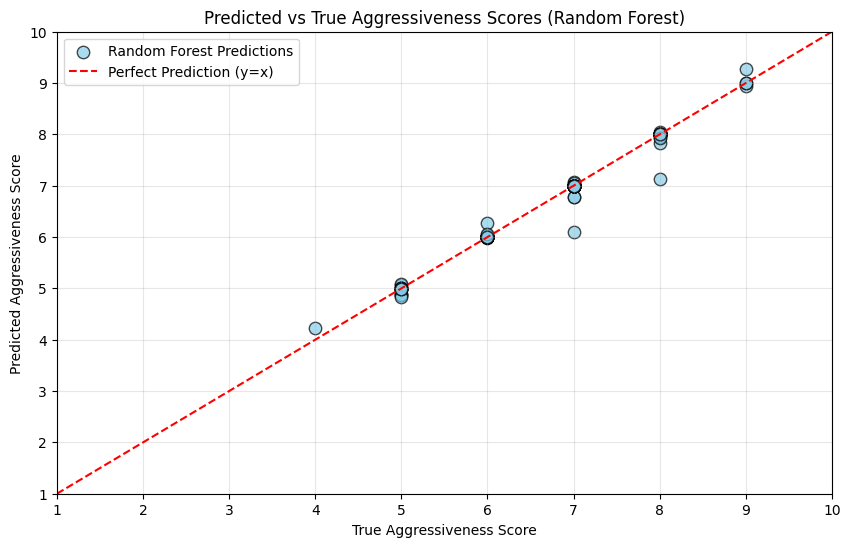

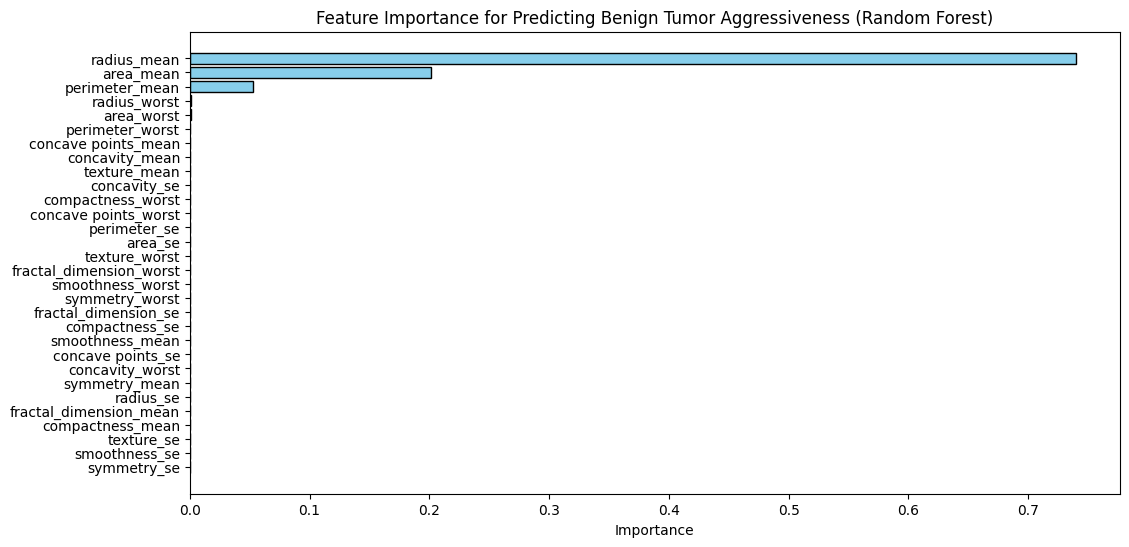

Top features contributing to the predicted aggressiveness scores:
                Feature  Importance
0           radius_mean    0.739487
3             area_mean    0.201319
2        perimeter_mean    0.053087
20         radius_worst    0.001292
23           area_worst    0.000757
22      perimeter_worst    0.000420
7   concave points_mean    0.000286
6        concavity_mean    0.000249
1          texture_mean    0.000245
16         concavity_se    0.000239
Patient 1 - Predicted Score: 8.00 | Top contributing features:
  - perimeter_mean: 87.46 (importance: 0.053)
  - area_mean: 566.30 (importance: 0.201)
  - radius_mean: 13.54 (importance: 0.739)

Patient 2 - Predicted Score: 5.06 | Top contributing features:
  - perimeter_mean: 85.63 (importance: 0.053)
  - area_mean: 520.00 (importance: 0.201)
  - radius_mean: 13.08 (importance: 0.739)

Patient 3 - Predicted Score: 8.00 | Top contributing features:
  - perimeter_mean: 60.34 (importance: 0.053)
  - area_mean: 273.90 (importance: 0.20

/tmp/ipython-input-2774966565.py:182: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  top_features = [(feature_names[j], patient_features[j], importances[j]) for j in top_features_idx]


In [59]:
# -------------------------------
# 0️⃣ Imports
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------
# 1️⃣ Prepare data
# -------------------------------
# Filter only benign patients
benign_df = df[df['diagnosis'] == 'B'].copy()

# Simulate an aggressiveness score for demonstration (replace with real clinical score)
benign_df['aggressiveness_score'] = np.clip(
    (benign_df['radius_mean'] / benign_df['radius_mean'].max() * 10).round(), 1, 10
)

X = benign_df.drop(columns=['id','Unnamed: 32','diagnosis','aggressiveness_score'])
y_score = benign_df['aggressiveness_score']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_score, test_size=0.3, random_state=42
)

# -------------------------------
# 2️⃣ Train regression models
# -------------------------------
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)

svm_reg = SVR(kernel='rbf')
svm_reg.fit(X_train, y_train)

# -------------------------------
# 3️⃣ Predictions
# -------------------------------
y_pred_lr = np.clip(lr_reg.predict(X_test), 1, 10)
y_pred_rf = np.clip(rf_reg.predict(X_test), 1, 10)
y_pred_svm = np.clip(svm_reg.predict(X_test), 1, 10)

# -------------------------------
# 4️⃣ Evaluate models
# -------------------------------
def print_regression_metrics(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"=== {name} Regression Metrics ===")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2 Score: {r2:.3f}\n")

print_regression_metrics("Linear Regression", y_test, y_pred_lr)
print_regression_metrics("Random Forest", y_test, y_pred_rf)
print_regression_metrics("SVM Regression", y_test, y_pred_svm)

# -------------------------------
# 5️⃣ Histogram of predicted scores (Random Forest)
# -------------------------------
plt.figure(figsize=(10,5))
plt.hist(y_pred_rf, bins=np.arange(0.5,11.5,1), rwidth=0.8, color='skyblue', edgecolor='black')
plt.xticks(range(1,11))
plt.xlabel("Predicted Aggressiveness Score (1-10)")
plt.ylabel("Number of Benign Patients")
plt.title("Distribution of Predicted Aggressiveness Scores (Random Forest)")
plt.show()

# -------------------------------
# 6️⃣ Scatter plot with labels
# -------------------------------
def label_risk(score):
    if score <= 3:
        return "Low"
    elif score <= 7:
        return "Medium"
    else:
        return "High"

labels_rf = [label_risk(s) for s in y_pred_rf]

plt.figure(figsize=(12,5))
scatter = plt.scatter(range(len(y_pred_rf)), y_pred_rf, c=y_pred_rf, cmap='viridis', s=80, edgecolor='k')
for i, txt in enumerate(labels_rf):
    plt.text(i, y_pred_rf[i]+0.2, txt, ha='center', fontsize=8, rotation=45)
plt.colorbar(scatter, label='Aggressiveness Score')
plt.xlabel("Benign Patient Index")
plt.ylabel("Predicted Aggressiveness Score (1-10)")
plt.title("Individual Predicted Aggressiveness Scores (Random Forest) with Labels")
plt.ylim(0, 11)
plt.yticks(range(1,11))
plt.show()

# -------------------------------
# 7️⃣ Interpretation & Summary
# -------------------------------
# Count number of patients per score
score_counts = pd.Series(y_pred_rf).value_counts().sort_index()
print("Number of patients per predicted score (1-10):")
print(score_counts)

# Count low/medium/high
risk_categories = pd.Series(labels_rf)
risk_counts = risk_categories.value_counts()
print("\nNumber of patients per risk category:")
print(risk_counts)

# Optional: textual summary
summary_text = f"""
Summary Interpretation:
- Total benign patients evaluated: {len(y_pred_rf)}
- Low risk (score 1-3): {risk_counts.get('Low',0)} patients
- Medium risk (score 4-7): {risk_counts.get('Medium',0)} patients
- High risk (score 8-10): {risk_counts.get('High',0)} patients
This shows how the model stratifies benign tumors based on aggressiveness,
allowing tailored follow-up or treatment intensity per patient.
"""
print(summary_text)

# -------------------------------
# 8️⃣ Scatter Plot: Predicted vs True Aggressiveness Scores
# -------------------------------
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_rf, c='skyblue', edgecolor='k', s=80, alpha=0.7, label='Random Forest Predictions')
plt.plot([1,10],[1,10], linestyle='--', color='red', label='Perfect Prediction (y=x)')
plt.xlabel("True Aggressiveness Score")
plt.ylabel("Predicted Aggressiveness Score")
plt.title("Predicted vs True Aggressiveness Scores (Random Forest)")
plt.xlim(1,10)
plt.ylim(1,10)
plt.xticks(range(1,11))
plt.yticks(range(1,11))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -------------------------------
# 9️⃣ Feature Importance (Random Forest)
# -------------------------------
importances = rf_reg.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Bar plot of feature importance
plt.figure(figsize=(12,6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue', edgecolor='k')
plt.gca().invert_yaxis()  # largest on top
plt.xlabel("Importance")
plt.title("Feature Importance for Predicting Benign Tumor Aggressiveness (Random Forest)")
plt.show()

print("Top features contributing to the predicted aggressiveness scores:")
print(feature_importance_df.head(10))

# -------------------------------
# 10️⃣ Explanation of Each Score
# -------------------------------
# For demonstration, we can create a textual explanation for the first 10 patients
explanations = []
for i in range(min(10, len(y_pred_rf))):
    patient_features = X.iloc[i]
    score = y_pred_rf[i]

    # Find top 3 contributing features for this patient
    top_features_idx = np.argsort(importances)[-3:]  # top 3 features
    top_features = [(feature_names[j], patient_features[j], importances[j]) for j in top_features_idx]

    explanation = f"Patient {i+1} - Predicted Score: {score:.2f} | Top contributing features:\n"
    for feat_name, feat_value, feat_imp in top_features:
        explanation += f"  - {feat_name}: {feat_value:.2f} (importance: {feat_imp:.3f})\n"
    explanations.append(explanation)

# Print explanations
for expl in explanations:
    print(expl)



**Clinical Interpretation**

Score 1–3 (Low risk): Small tumors with low radius_mean and area_mean — likely need minimal follow-up.

Score 4–7 (Medium risk): Moderate size tumors — closer monitoring or intermediate treatment may be warranted.

Score 8–10 (High risk): Large radius_mean and area_mean — even if benign, these may behave aggressively locally, so require closer surveillance.

The model quantifies tumor aggressiveness within benign cases, giving clinicians a data-driven way to prioritize follow-up and treatment intensity.